In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv('../data/processed_data.csv')
df.head()

,day,month,totalPoints,cumulativePoints,rollingAvgPoints,taskCompleted,taskMissed,pointsGain,pointsDeduct,mindStatus
0,-0.156136,-0.670325,0.009448,-1.068713,-0.427052,-1.464774,-1.015888,-0.978629,-0.861785,0
1,-0.998353,-0.377616,-0.054020,-1.046843,-0.427052,-0.895381,-0.037349,-0.511597,-0.356667,0
2,-0.878037,0.207801,0.421989,-0.992170,0.159859,-0.325988,0.941190,0.364089,-0.356667,0
3,-0.757720,-0.084908,-0.688700,-1.014039,-0.114866,-0.895381,0.941190,-0.803492,0.401010,0
4,-0.637403,-0.084908,-1.259912,-1.075274,-0.589389,-1.464774,-0.037349,-1.562420,0.653569,0


In [5]:
window_size = 7
num_features = df.shape[1] - 1

features = df.drop(columns=['mindStatus'], axis=1).values
labels = df['mindStatus'].values

In [6]:
X, y = [], []

for i in range(len(df) - window_size):
    X.append(features[i:i+window_size])
    y.append(labels[i+window_size])

X = np.array(X)
y = np.array(y)

In [7]:
print(f"Shape of X: {X.shape}")  
print(f"Shape of y: {y.shape}")

Shape of X: (124, 7, 9)
Shape of y: (124,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], num_features), return_sequences=True),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 7, 64)             18944     
                                                                 
 lstm_2 (LSTM)               (None, 64)                33024     
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 6)                 198       
                                                                 
Total params: 54246 (211.90 KB)
Trainable params: 54246 (211.90 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
5/5 [==============================] - 15s 957ms/step - loss: 1.7731 - accuracy: 0.1772 - val_loss: 1.6960 - val_accuracy: 0.4000
Epoch 2/20
5/5 [==============================] - 0s 54ms/step - loss: 1.6701 - accuracy: 0.4937 - val_loss: 1.5754 - val_accuracy: 0.6000
Epoch 3/20
5/5 [==============================] - 0s 48ms/step - loss: 1.5532 - accuracy: 0.6456 - val_loss: 1.4312 - val_accuracy: 0.6500
Epoch 4/20
5/5 [==============================] - 0s 83ms/step - loss: 1.4162 - accuracy: 0.6709 - val_loss: 1.2477 - val_accuracy: 0.6500
Epoch 5/20
5/5 [==============================] - 0s 59ms/step - loss: 1.2502 - accuracy: 0.6329 - val_loss: 1.0890 - val_accuracy: 0.6000
Epoch 6/20
5/5 [==============================] - 0s 38ms/step - loss: 1.1140 - accuracy: 0.6076 - val_loss: 0.9883 - val_accuracy: 0.6500
Epoch 7/20
5/5 [==============================] - 0s 37ms/step - loss: 1.0201 - accuracy: 0.6076 - val_loss: 0.9362 - val_accuracy: 0.7500
Epoch 8/20
5/5 [=========

In [24]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
predicted_classes

1/1 [==============================] - 0s 88ms/step


array([5, 2, 2, 1, 2, 4, 2, 2, 2, 3, 3, 2, 2, 2, 5, 2, 1, 2, 2, 2, 2, 3,
       2, 4, 2], dtype=int64)

In [27]:
accuracy = accuracy_score(y_test, predicted_classes)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.00%


Matplotlib is building the font cache; this may take a moment.
d:\web dev projects\Schedrix\server\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\web dev projects\Schedrix\server\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\web dev projects\Schedrix\server\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.40      0.57         5
           2       0.81      1.00      0.90        13
           3       0.33      1.00      0.50         1
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         2

    accuracy                           0.80        25
   macro avg       0.69      0.68      0.63        25
weighted avg       0.84      0.80      0.78        25



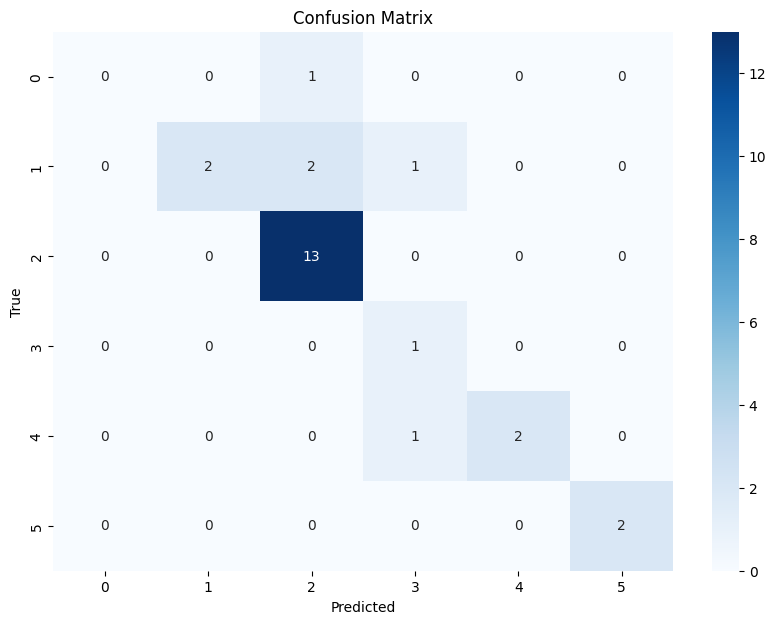

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, predicted_classes))
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save('../ml_models_service/lstm_model.h5')

d:\web dev projects\Schedrix\server\tf-env\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
